# Can we trust the confidence score?

Every label the model produces comes with a **confidence**. If it were trustworthy,
wrong labels would carry lower confidence than right ones.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    containment, extract_gold, resolve_old_gt_path, tokenize,
)

MODELS = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b']
EXTRACTOR = 'pdfplumber'
SAMPLES = range(1, 11)


## Step 1 — Load the labeled JSON

One entry per **line** of the PDF, each with a label and a confidence.


In [2]:
lines = json.loads(P.labeled_path(P.make_tag('llama3.1:8b', EXTRACTOR), 1)
                   .read_text(encoding='utf-8'))
print(f'{len(lines)} lines in sample 1')
display(pd.DataFrame(lines)[['text', 'label', 'confidence']].head(4))


78 lines in sample 1


,text,label,confidence
0,DATA MANAGEMENT AND SHARING PLAN,title,1.0
1,Element 1: Data Type:,section.title,1.0
2,A. Types and amount of scientific data expecte...,question.text,1.0
3,This secondary data analysis project will anal...,answer.text,1.0


## Step 2 — Join the lines back into items

A paragraph is several lines in the PDF but **one item** in the annotation. So
neighbouring lines with the same label are put back together — exactly what the
pipeline does when it builds its final output.


In [3]:
def join_lines(lines):
    """Neighbouring lines with the same label become one item."""
    items, current = [], None
    for line in lines:
        if current is not None and current['label'] == line['label']:
            current['text'] += ' ' + line['text']
            current['line_confidences'].append(float(line['confidence']))
        else:
            if current is not None:
                items.append(current)
            current = {'label': line['label'], 'text': line['text'],
                       'line_confidences': [float(line['confidence'])]}
    if current is not None:
        items.append(current)
    return items


items = join_lines(lines)
print(f'{len(lines)} lines  ->  {len(items)} items')


78 lines  ->  30 items


## Step 3 — One confidence per item: the lowest of its lines

A paragraph is only as trustworthy as its shakiest line.


In [4]:
biggest = max(items, key=lambda it: len(it['line_confidences']))
print(f"an item made of {len(biggest['line_confidences'])} lines")
print(f"  line confidences : {biggest['line_confidences']}")
print(f"  lowest           : {min(biggest['line_confidences'])}  <- the item's confidence")


an item made of 12 lines
  line confidences : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  lowest           : 1.0  <- the item's confidence


## Step 4 — Check every item against the annotation

The same steps for every model and all 10 documents: load, join, take the lowest
confidence, compare with the annotation.


In [5]:
def true_label_of(item, annotation):
    """The label of the annotation paragraph this item belongs to, or None."""
    words = tokenize(item['text'])
    if len(words) < 3:
        return None
    best_score, best_label = 0.0, None
    for gold_text, gold_label in annotation:
        score = containment(words, tokenize(gold_text))
        if score > best_score:
            best_score, best_label = score, gold_label
    return best_label if best_score >= 0.75 else None


rows = []
for sample in SAMPLES:
    annotation = extract_gold(resolve_old_gt_path(sample))
    for model in MODELS:
        path = P.labeled_path(P.make_tag(model, EXTRACTOR), sample)
        for item in join_lines(json.loads(path.read_text(encoding='utf-8'))):
            true_label = true_label_of(item, annotation)
            if true_label is None:
                continue
            rows.append({'model': model,
                         'confidence': min(item['line_confidences']),
                         'correct': item['label'] == true_label,
                         'true label': true_label,
                         'model said': item['label'],
                         'text': item['text']})

df = pd.DataFrame(rows)
print(f'{len(df)} items checked across {len(MODELS)} models and 10 documents')


768 items checked across 3 models and 10 documents


## The result


In [6]:
table = (df.groupby('model')
         .apply(lambda d: pd.Series({
             'Accuracy, %': d['correct'].mean() * 100,
             'Total confidence, %': d['confidence'].mean() * 100,
             'Confidence for correct answer, %':
                 d[d['correct']]['confidence'].mean() * 100,
             'Confidence for incorrect answer, %':
                 d[~d['correct']]['confidence'].mean() * 100,
         }), include_groups=False)
         .reindex(MODELS))
table.index.name = 'Model'
display(table.style.format('{:.1f}'))


,"Accuracy, %","Total confidence, %","Confidence for correct answer, %","Confidence for incorrect answer, %"
Model,,,,
llama3.1:8b,49.1,89.2,89.4,89.0
gemma4:e4b,75.5,94.7,95.9,91.1
llama3.3:70b,75.1,86.5,87.6,83.2


**Read the last two columns.** If confidence worked, the last column would be much
lower than the one before it — mistakes arriving with visible doubt. They are almost
the same.

**And compare the first two.** Every model claims far more confidence than its
accuracy justifies.


### A real example from each case

Splitting items by confidence (high = 0.9 or more) and by whether they were right.
The second row is the one that matters.


In [7]:
M = MODELS[0]
d = df[df['model'] == M].copy()
d['high confidence'] = d['confidence'] >= 0.9

picks = []
for high, ok, name in ((True, True, 'high confidence + correct'),
                       (True, False, 'high confidence + INCORRECT'),
                       (False, True, 'low confidence + correct'),
                       (False, False, 'low confidence + incorrect')):
    sub = d[(d['high confidence'] == high) & (d['correct'] == ok)]
    if len(sub):
        r = sub.sort_values('confidence', ascending=not high).iloc[0]
        picks.append({'case': name, 'confidence': f"{r['confidence']:.2f}",
                      'true label': r['true label'],
                      'model said': r['model said'],
                      'text': r['text'][:64]})
    else:
        picks.append({'case': name, 'confidence': '—', 'true label': '—',
                      'model said': '—', 'text': '(no items in this case)'})

print(f'{M}\n')
display(pd.DataFrame(picks).set_index('case'))


llama3.1:8b



,confidence,true label,model said,text
case,,,,
high confidence + correct,1.00,title,title,DATA MANAGEMENT AND SHARING PLAN
high confidence + INCORRECT,1.00,question.text,section.title,B. Scientific data that will be preserved and ...
low confidence + correct,0.10,answer.text,answer.text,The proposed research in this proposal include...
low confidence + incorrect,0.55,section.description,question.text,Data management plans should provide a plan fo...


## Large language models' mean confidence scores for correct and incorrect answers

The two bars per model are the last two columns of the table above. The thin line on
each bar shows the spread (± 1 SD) of the individual items behind it.


saved for slides -> Report-doc\confidence_correct_vs_incorrect.png


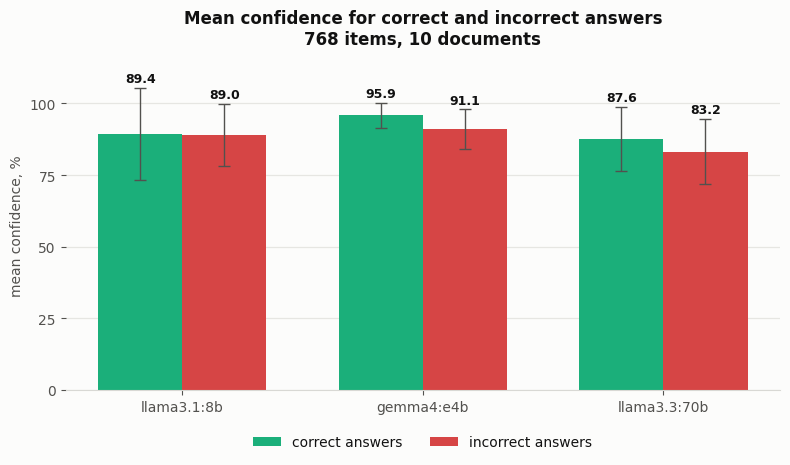

In [8]:
GOOD, BAD = '#1baf7a', '#d64545'
INK, MUTED, SURFACE, GRID = '#111111', '#52514e', '#fcfcfb', '#e6e6e2'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})

means_ok, means_bad, sd_ok, sd_bad = [], [], [], []
for model in MODELS:
    d = df[df['model'] == model]
    right, wrong = d[d['correct']]['confidence'], d[~d['correct']]['confidence']
    means_ok.append(right.mean() * 100); sd_ok.append(right.std() * 100)
    means_bad.append(wrong.mean() * 100); sd_bad.append(wrong.std() * 100)

x = np.arange(len(MODELS))
w = 0.35
fig, ax = plt.subplots(figsize=(8.0, 4.8))

b1 = ax.bar(x - w / 2, means_ok, w, yerr=sd_ok, capsize=4, color=GOOD,
            error_kw={'ecolor': MUTED, 'elinewidth': 1}, label='correct answers')
b2 = ax.bar(x + w / 2, means_bad, w, yerr=sd_bad, capsize=4, color=BAD,
            error_kw={'ecolor': MUTED, 'elinewidth': 1}, label='incorrect answers')
for bars, means, sds in ((b1, means_ok, sd_ok), (b2, means_bad, sd_bad)):
    for bar, value, sd in zip(bars, means, sds):
        # above the whisker cap, so the label never sits on the error bar
        ax.text(bar.get_x() + bar.get_width() / 2, value + sd + 2, f'{value:.1f}',
                ha='center', fontsize=9, fontweight='bold', color=INK)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylabel('mean confidence, %')
ax.set_ylim(0, 115)
ax.set_yticks([0, 25, 50, 75, 100])
ax.grid(axis='y', color=GRID, linewidth=0.9)
ax.set_axisbelow(True)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.set_title("Mean confidence for correct and incorrect answers\n"
             f"{len(df)} items, 10 documents", pad=12)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

out = Path('Report-doc/confidence_correct_vs_incorrect.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
print(f'saved for slides -> {out}')
plt.show()


**The pairs are nearly the same height for every model**, and the error bars overlap
almost completely — so the confidence of a wrong answer is not distinguishable from
that of a right one.


## Conclusion

**The confidence score cannot be used to catch mistakes.** A high number does not
mean a correct label, so it must not be used to accept a label automatically.
